# U-Net Skip Connection Ablation — Football Semantic Segmentation

| Exp | L1 skip | L2 skip | L3 skip |
|-----|---------|---------|----------|
| 1 | ✅ | ❌ | ❌ |
| 2 | ❌ | ✅ | ❌ |
| 3 | ❌ | ❌ | ✅ |
| 4 | ✅ | ✅ | ✅ |

In [4]:
import os, random, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [5]:
# ── Config ───────────────────────────────────────────────────────────────────
DATA_ROOT    = Path('/kaggle/input/datasets/sadhliroomyprime/football-semantic-segmentation')
IMAGE_DIR    = DATA_ROOT / 'images'
SAVE_DIR     = Path('/kaggle/working/checkpoints')
SAVE_DIR.mkdir(exist_ok=True)

NUM_CLASSES  = 11
IMAGE_SIZE   = (256, 256)
BATCH_SIZE   = 8
NUM_EPOCHS   = 10
LR           = 0.0005
WEIGHT_DECAY = 1e-5
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15

CLASS_NAMES = [
    'Team A', 'Team B', 'Ground', 'Advertisements', 'Audience',
    'Goal Bar', 'Referee', 'Ball', 'Goalkeeper A', 'Goalkeeper B',
    'Coaches & Officials'
]

# Actual colors found in ___fuse.png masks → class index
COLOR_TO_CLASS = {
    (254, 233,   3): 0,   # Team A
    (255, 160,   1): 1,   # Team B
    (137, 126, 126): 2,   # Ground
    ( 27,  71, 151): 3,   # Advertisements
    (111,  48, 253): 4,   # Audience
    (255,   0,  29): 5,   # Goal Bar
    (238, 171, 171): 6,   # Referee
    (201,  19, 223): 7,   # Ball
    (255, 159,   0): 8,   # Goalkeeper A
    (255, 235,   0): 9,   # Goalkeeper B
    (  0,   0,   0): 10,  # Coaches & Officials
}

COCO_PALETTE = [list(c) for c in COLOR_TO_CLASS.keys()]

print('Config OK')
print('Classes:')
for color, idx in COLOR_TO_CLASS.items():
    print(f'  {idx:2d}: {CLASS_NAMES[idx]:25s} → RGB{color}')

Config OK
Classes:
   0: Team A                    → RGB(254, 233, 3)
   1: Team B                    → RGB(255, 160, 1)
   2: Ground                    → RGB(137, 126, 126)
   3: Advertisements            → RGB(27, 71, 151)
   4: Audience                  → RGB(111, 48, 253)
   5: Goal Bar                  → RGB(255, 0, 29)
   6: Referee                   → RGB(238, 171, 171)
   7: Ball                      → RGB(201, 19, 223)
   8: Goalkeeper A              → RGB(255, 159, 0)
   9: Goalkeeper B              → RGB(255, 235, 0)
  10: Coaches & Officials       → RGB(0, 0, 0)


In [10]:
# ── Inspect mask to understand its format ─────────────────────────────────────
all_jpgs = sorted(IMAGE_DIR.glob('*.jpg'))
print(f'JPG files found: {len(all_jpgs)}')

sample_img_path  = all_jpgs[0]
sample_mask_path = Path(str(sample_img_path) + '___save.png')

print(f'Sample image : {sample_img_path.name}')
print(f'Mask exists  : {sample_mask_path.exists()}')

sample_mask = Image.open(sample_mask_path)
mask_arr    = np.array(sample_mask)
print(f'Mask mode    : {sample_mask.mode}')
print(f'Mask shape   : {mask_arr.shape}')
print(f'Unique vals  : {np.unique(mask_arr.reshape(-1, mask_arr.shape[-1]) if mask_arr.ndim==3 else mask_arr)}')

JPG files found: 100
Sample image : Frame 1  (1).jpg
Mask exists  : True
Mask mode    : RGBA
Mask shape   : (1080, 1920, 4)
Unique vals  : [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  28  30  31  32  33  34  35  36  37
  38  39  40  41  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75
  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93
  94  95  96  97  98  99 100 101 102 103 105 106 107 108 109 110 111 112
 113 114 115 116 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 136 137 138 140 141 142 143 144 145 146 147 148 149 150 151 152
 153 155 156 157 158 159 160 161 163 164 165 166 167 168 169 170 171 172
 173 174 175 176 178 179 180 181 182 183 184 185 186 187 188 189 190 191
 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 210
 211 212 213 214 215 216 217 218 219 220 221 222 223 224 2

In [11]:
# ── Dataset ───────────────────────────────────────────────────────────────────
# Uses ___fuse.png masks — RGB colors mapped to class indices via COCO JSON

class FootballSegDataset(Dataset):
    def __init__(self, image_paths, image_size=(256,256), augment=False):
        self.image_paths = image_paths
        self.image_size  = image_size
        self.augment     = augment

        # Build lookup: color tuple → class index
        self.color_to_class = COLOR_TO_CLASS
        # Precompute as numpy arrays for fast matching
        self.colors  = np.array(list(COLOR_TO_CLASS.keys()),  dtype=np.uint8)   # (C, 3)
        self.indices = np.array(list(COLOR_TO_CLASS.values()), dtype=np.uint8)  # (C,)

    def __len__(self): return len(self.image_paths)

    def _mask_to_index(self, mask_rgb):
        """Convert (H,W,3) RGB mask to (H,W) class index mask."""
        H, W, _ = mask_rgb.shape
        cls_mask = np.zeros((H, W), dtype=np.uint8)
        for color, idx in zip(self.colors, self.indices):
            match = np.all(mask_rgb == color, axis=-1)
            cls_mask[match] = idx
        return cls_mask

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        fuse_path = img_path + '___fuse.png'

        image    = Image.open(img_path).convert('RGB')
        fuse_img = Image.open(fuse_path).convert('RGB')   # drop alpha
        mask_arr = np.array(fuse_img)                      # (H, W, 3)
        cls_mask = self._mask_to_index(mask_arr)           # (H, W)
        mask     = Image.fromarray(cls_mask)

        image = image.resize((self.image_size[1], self.image_size[0]), Image.BILINEAR)
        mask  = mask.resize( (self.image_size[1], self.image_size[0]), Image.NEAREST)

        if self.augment:
            image, mask = self._augment(image, mask)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        mask  = torch.from_numpy(np.array(mask)).long().clamp(0, NUM_CLASSES-1)
        return image, mask

    def _augment(self, image, mask):
        if random.random() > 0.5:
            image = TF.hflip(image); mask = TF.hflip(mask)
        if random.random() > 0.8:
            image = TF.vflip(image); mask = TF.vflip(mask)
        angle = random.uniform(-15, 15)
        image = TF.rotate(image, angle); mask = TF.rotate(mask, angle)
        image = TF.adjust_brightness(image, 0.8 + 0.4*random.random())
        image = TF.adjust_contrast(image,   0.8 + 0.4*random.random())
        return image, mask

print('Dataset class defined.')

Dataset class defined.


In [12]:
# ── Build splits (ordered — no shuffle to avoid video frame leakage) ──────────
image_files = []
for p in sorted(IMAGE_DIR.glob('*.jpg')):
    if Path(str(p) + '___fuse.png').exists():
        image_files.append(str(p))

print(f'Paired samples: {len(image_files)}')
assert len(image_files) > 0, 'No paired samples found!'

# Ordered split: first 70% train, next 15% val, last 15% test
n       = len(image_files)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_files = image_files[:n_train]
val_files   = image_files[n_train : n_train + n_val]
test_files  = image_files[n_train + n_val:]

print(f'Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}')

train_ds = FootballSegDataset(train_files, IMAGE_SIZE, augment=True)
val_ds   = FootballSegDataset(val_files,   IMAGE_SIZE, augment=False)
test_ds  = FootballSegDataset(test_files,  IMAGE_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
print('✅ Loaders ready.')

Paired samples: 100
Train: 70 | Val: 15 | Test: 15
✅ Loaders ready.


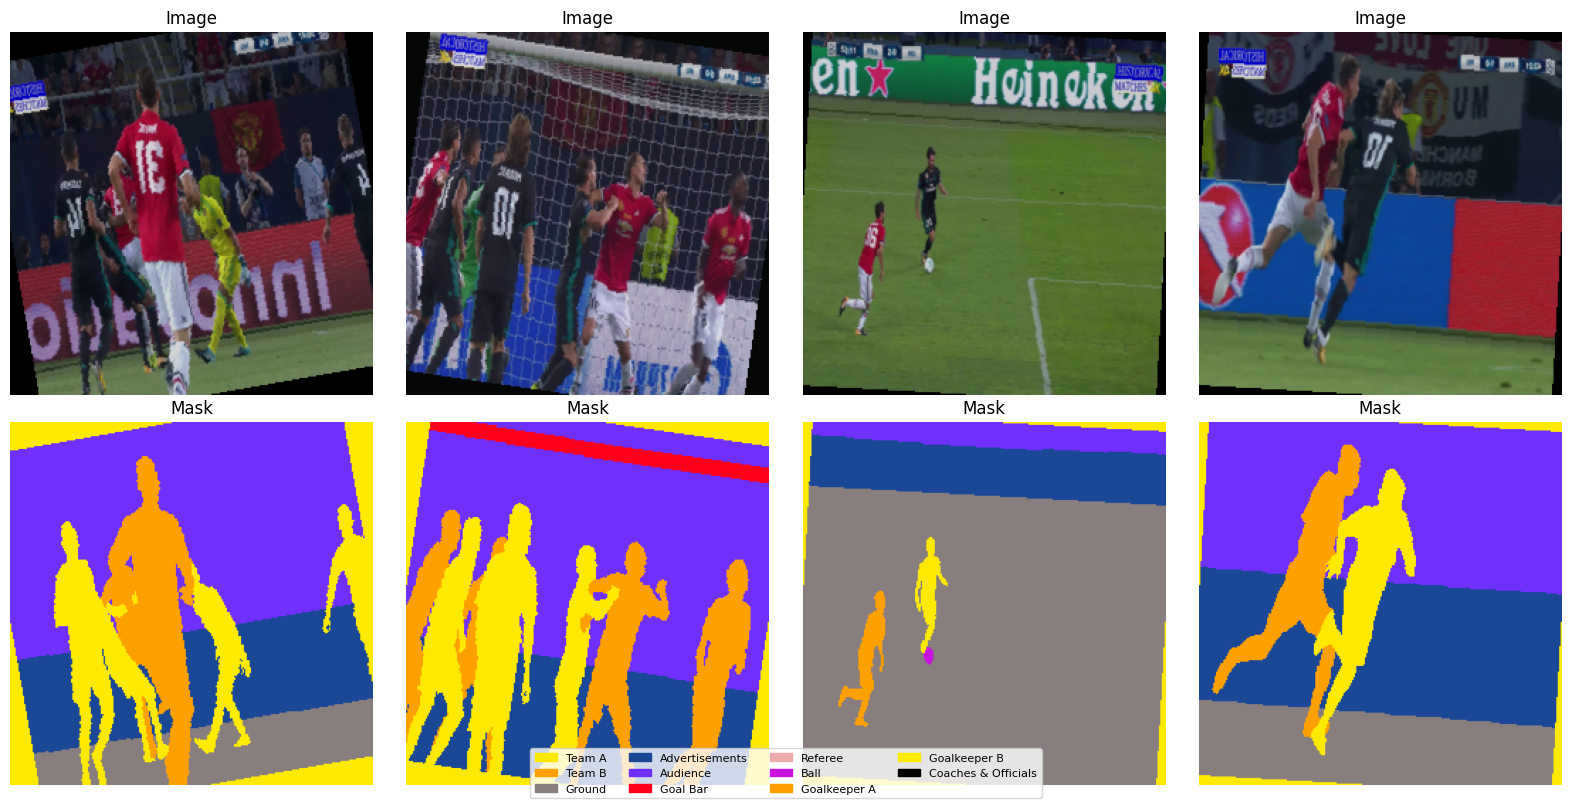

In [13]:
# ── Quick visual check ────────────────────────────────────────────────────────
mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
def denorm(t): return np.clip(t.permute(1,2,0).cpu().numpy()*std+mean, 0, 1)
def colorise(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for color, idx in COLOR_TO_CLASS.items():
        rgb[mask_np==idx] = list(color)
    return rgb

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(16,8))
for i in range(4):
    axes[0,i].imshow(denorm(imgs[i])); axes[0,i].set_title('Image'); axes[0,i].axis('off')
    axes[1,i].imshow(colorise(masks[i].numpy())); axes[1,i].set_title('Mask'); axes[1,i].axis('off')
patches = [mpatches.Patch(color=[c/255 for c in color], label=CLASS_NAMES[idx])
           for color, idx in COLOR_TO_CLASS.items()]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/sample_batch.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# ── U-Net Architecture ────────────────────────────────────────────────────────
# skip_mask = [L1, L2, L3]  True = skip connection active
# L1 = shallowest (64ch), L2 = middle (128ch), L3 = deepest (256ch)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=11, skip_mask=(True,True,True)):
        super().__init__()
        self.skip_mask = list(skip_mask)
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder — input channels depend on whether skip is active
        self.up3  = nn.ConvTranspose2d(512, 512, 2, stride=2)
        self.dec3 = DoubleConv(512 + (256 if skip_mask[2] else 0), 256)

        self.up2  = nn.ConvTranspose2d(256, 256, 2, stride=2)
        self.dec2 = DoubleConv(256 + (128 if skip_mask[1] else 0), 128)

        self.up1  = nn.ConvTranspose2d(128, 128, 2, stride=2)
        self.dec1 = DoubleConv(128 + (64  if skip_mask[0] else 0), 64)

        self.out_conv = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)               # [B,  64, H,   W  ]
        e2 = self.enc2(self.pool(e1))   # [B, 128, H/2, W/2]
        e3 = self.enc3(self.pool(e2))   # [B, 256, H/4, W/4]
        b  = self.bottleneck(self.pool(e3))  # [B, 512, H/8, W/8]

        d3 = self.up3(b)
        if self.skip_mask[2]: d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        if self.skip_mask[1]: d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if self.skip_mask[0]: d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


# Sanity check all 4 configs
for name, mask in [
    ('Exp1 L1 only', [True, False, False]),
    ('Exp2 L2 only', [False, True, False]),
    ('Exp3 L3 only', [False, False, True]),
    ('Exp4 All',     [True,  True,  True]),
]:
    m   = UNet(num_classes=NUM_CLASSES, skip_mask=mask)
    out = m(torch.randn(2, 3, *IMAGE_SIZE))
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:20s} | output={tuple(out.shape)} | params={params:,}')

Exp1 L1 only         | output=(2, 11, 256, 256) | params=8,426,251
Exp2 L2 only         | output=(2, 11, 256, 256) | params=8,536,843
Exp3 L3 only         | output=(2, 11, 256, 256) | params=8,979,211
Exp4 All             | output=(2, 11, 256, 256) | params=9,163,531


In [15]:
# ── Loss & Metrics ────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6): super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        t_oh  = F.one_hot(targets, logits.size(1)).permute(0,3,1,2).float()
        dims  = (0,2,3)
        inter = (probs * t_oh).sum(dims)
        union = probs.sum(dims) + t_oh.sum(dims)
        return 1 - ((2*inter + self.smooth) / (union + self.smooth)).mean()

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

def compute_metrics(logits, targets, num_classes, smooth=1e-6):
    preds = logits.argmax(dim=1)
    ious, dices = [], []
    for c in range(num_classes):
        pc = (preds==c); tc = (targets==c)
        inter = (pc & tc).sum().item()
        union = (pc | tc).sum().item()
        if union == 0: continue
        ious.append((inter+smooth)/(union+smooth))
        dices.append((2*inter+smooth)/(pc.sum().item()+tc.sum().item()+smooth))
    return (np.mean(ious) if ious else 0.0), (np.mean(dices) if dices else 0.0)

print('Loss & metrics defined.')

Loss & metrics defined.


In [16]:
# ── Training utilities ────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    tot_loss, tot_iou, tot_dice, n = 0,0,0,0
    for imgs, masks in tqdm(loader, leave=False, desc='train'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        with torch.no_grad():
            iou, dice = compute_metrics(logits, masks, NUM_CLASSES)
        bs = imgs.size(0)
        tot_loss+=loss.item()*bs; tot_iou+=iou*bs; tot_dice+=dice*bs; n+=bs
    return tot_loss/n, tot_iou/n, tot_dice/n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    tot_loss, tot_iou, tot_dice, n = 0,0,0,0
    for imgs, masks in tqdm(loader, leave=False, desc='eval'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        iou, dice = compute_metrics(logits, masks, NUM_CLASSES)
        bs = imgs.size(0)
        tot_loss+=loss.item()*bs; tot_iou+=iou*bs; tot_dice+=dice*bs; n+=bs
    return tot_loss/n, tot_iou/n, tot_dice/n

print('Training utilities defined.')

Training utilities defined.


In [17]:
# ── Run experiment ────────────────────────────────────────────────────────────
def run_experiment(name, skip_mask, num_epochs=NUM_EPOCHS):
    print(f'\n{"="*55}\n  {name}\n  Skips: L1={skip_mask[0]} L2={skip_mask[1]} L3={skip_mask[2]}\n{"="*55}')
    model     = UNet(num_classes=NUM_CLASSES, skip_mask=skip_mask).to(DEVICE)
    criterion = CombinedLoss()
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    ckpt      = SAVE_DIR / f'{name}_best.pth'

    history = {k:[] for k in ['tr_loss','vl_loss','tr_iou','vl_iou','tr_dice','vl_dice']}
    best_iou = 0.0

    for epoch in range(1, num_epochs+1):
        tr_loss, tr_iou, tr_dice = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_iou, vl_dice = evaluate(model, val_loader, criterion)
        scheduler.step(vl_iou)
        for k,v in zip(history, [tr_loss,vl_loss,tr_iou,vl_iou,tr_dice,vl_dice]): history[k].append(v)
        if vl_iou > best_iou:
            best_iou = vl_iou; torch.save(model.state_dict(), ckpt)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Ep {epoch:3d}/{num_epochs} | Loss {tr_loss:.4f}/{vl_loss:.4f} | '
                  f'IoU {tr_iou:.4f}/{vl_iou:.4f} | Dice {tr_dice:.4f}/{vl_dice:.4f}')

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    te_loss, te_iou, te_dice = evaluate(model, test_loader, criterion)
    print(f'\n→ TEST  IoU={te_iou:.4f}  Dice={te_dice:.4f}')
    return model, history, {'loss':te_loss,'iou':te_iou,'dice':te_dice}

print('run_experiment() defined.')

run_experiment() defined.


In [18]:
# ── Run all 4 experiments ─────────────────────────────────────────────────────
EXPERIMENTS = [
    ('Exp1_L1_only', [True,  False, False]),
    ('Exp2_L2_only', [False, True,  False]),
    ('Exp3_L3_only', [False, False, True ]),
    ('Exp4_All',     [True,  True,  True ]),
]

all_histories, all_metrics, all_models = {}, {}, {}
for name, mask in EXPERIMENTS:
    model, history, metrics = run_experiment(name, mask)
    all_histories[name] = history
    all_metrics[name]   = metrics
    all_models[name]    = model

print('\n✅ All experiments done!')


  Exp1_L1_only
  Skips: L1=True L2=False L3=False


train:   0%|          | 0/9 [00:00<?, ?it/s]

eval:   0%|          | 0/2 [00:00<?, ?it/s]

Ep   1/10 | Loss 1.3718/1.5388 | IoU 0.1687/0.1416 | Dice 0.2206/0.1958


train:   0%|          | 0/9 [00:00<?, ?it/s]

...

train:   0%|          | 0/9 [00:00<?, ?it/s]

eval:   0%|          | 0/2 [00:00<?, ?it/s]

Ep  10/10 | Loss 0.5643/0.7771 | IoU 0.4359/0.3252 | Dice 0.5043/0.3961


eval:   0%|          | 0/2 [00:00<?, ?it/s]


→ TEST  IoU=0.3519  Dice=0.4107

✅ All experiments done!


In [19]:
import json
import numpy as np
from PIL import Image
from pathlib import Path

IMAGE_DIR = Path('/kaggle/input/datasets/sadhliroomyprime/football-semantic-segmentation/images')
DATA_ROOT = IMAGE_DIR.parent

# Load COCO JSON
json_files = list(DATA_ROOT.rglob('*.json'))
print('JSON found:', json_files)

with open(json_files[0]) as f:
    coco = json.load(f)

print('\nCategories:')
for cat in coco['categories']:
    print(cat)

# Check unique RGB triplets in fuse mask
all_jpgs  = sorted(IMAGE_DIR.glob('*.jpg'))
fuse_path = Path(str(all_jpgs[0]) + '___fuse.png')
fuse      = np.array(Image.open(fuse_path).convert('RGB'))
pixels    = fuse.reshape(-1, 3)
unique_colors = np.unique(pixels, axis=0)
print(f'\nUnique RGB triplets in fuse mask ({len(unique_colors)} total):')
for c in unique_colors:
    print(list(c))

JSON found: [PosixPath('/kaggle/input/datasets/sadhliroomyprime/football-semantic-segmentation/COCO_Football Pixel.json')]

Categories:
{'id': 1393250, 'name': 'Goal Bar', 'supercategory': 'Goal Bar', 'isthing': 1, 'color': [98, 66, 21]}
{'id': 1392807, 'name': 'Referee', 'supercategory': 'Referee', 'isthing': 1, 'color': [167, 64, 21]}
{'id': 1392806, 'name': 'Advertisements', 'supercategory': 'Advertisements', 'isthing': 1, 'color': [166, 64, 21]}
{'id': 1392805, 'name': 'Ground', 'supercategory': 'Ground', 'isthing': 1, 'color': [165, 64, 21]}
{'id': 1392804, 'name': 'Ball', 'supercategory': 'Ball', 'isthing': 1, 'color': [164, 64, 21]}
{'id': 1392803, 'name': 'Coaches & Officials', 'supercategory': 'Coaches & Officials', 'isthing': 1, 'color': [163, 64, 21]}
{'id': 1392802, 'name': 'Audience', 'supercategory': 'Audience', 'isthing': 1, 'color': [162, 64, 21]}
{'id': 1392801, 'name': 'Goalkeeper B', 'supercategory': 'Goalkeeper B', 'isthing': 1, 'color': [161, 64, 21]}
{'id': 139280

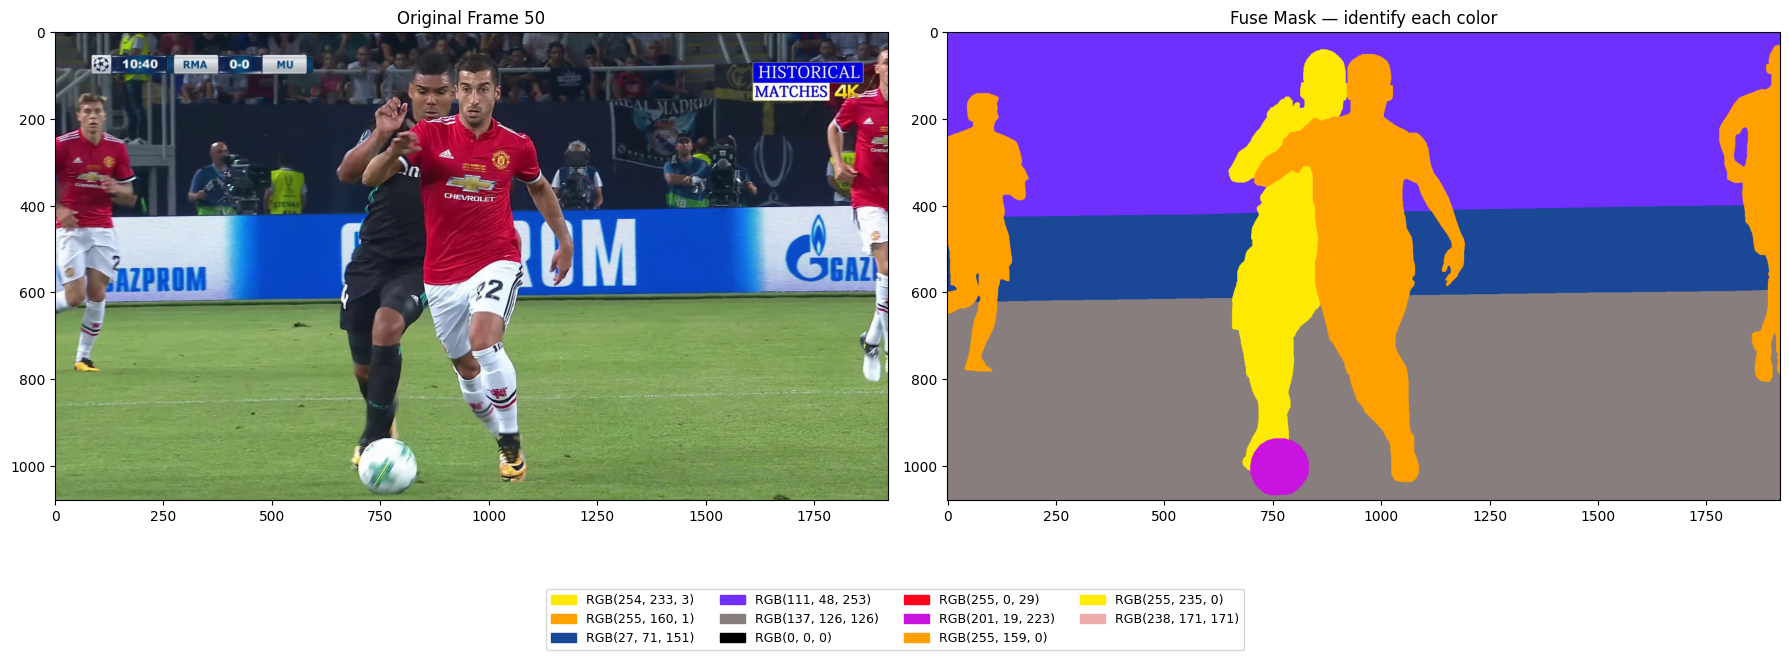

In [20]:
# Show each unique color as a patch so we can manually match to class names
actual_colors = [
    (254, 233,   3),
    (255, 160,   1),
    ( 27,  71, 151),
    (111,  48, 253),
    (137, 126, 126),
    (  0,   0,   0),
    (255,   0,  29),
    (201,  19, 223),
    (255, 159,   0),
    (255, 235,   0),
    (238, 171, 171),
]

# Show a sample frame with its mask side by side, with color legend
img_path  = image_files[20]   # pick a middle frame
fuse_path = img_path + '___fuse.png'

img  = np.array(Image.open(img_path).convert('RGB'))
fuse = np.array(Image.open(fuse_path).convert('RGB'))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(img);  axes[0].set_title('Original Frame 50')
axes[1].imshow(fuse); axes[1].set_title('Fuse Mask — identify each color')

# Add color patches as legend
patches = [mpatches.Patch(color=[c/255 for c in col], label=f'RGB{col}')
           for col in actual_colors]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.savefig('/kaggle/working/color_identification.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# ── Results table ─────────────────────────────────────────────────────────────
LABELS = {
    'Exp1_L1_only': 'Exp 1 — Level 1 skip only',
    'Exp2_L2_only': 'Exp 2 — Level 2 skip only',
    'Exp3_L3_only': 'Exp 3 — Level 3 skip only',
    'Exp4_All':     'Exp 4 — All skips (standard U-Net)',
}

rows = []
for name, _ in EXPERIMENTS:
    h  = all_histories[name]
    te = all_metrics[name]
    rows.append({
        'Experiment':    LABELS[name],
        'Best Val IoU':  f"{max(h['vl_iou']):.4f}",
        'Best Val Dice': f"{max(h['vl_dice']):.4f}",
        'Test IoU':      f"{te['iou']:.4f}",
        'Test Dice':     f"{te['dice']:.4f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('/kaggle/working/results.csv', index=False)

                        Experiment Best Val IoU Best Val Dice Test IoU Test Dice
         Exp 1 — Level 1 skip only       0.3095        0.3861   0.3573    0.4172
         Exp 2 — Level 2 skip only       0.3300        0.4110   0.3763    0.4317
         Exp 3 — Level 3 skip only       0.2906        0.3701   0.3290    0.3805
Exp 4 — All skips (standard U-Net)       0.3258        0.4007   0.3519    0.4107


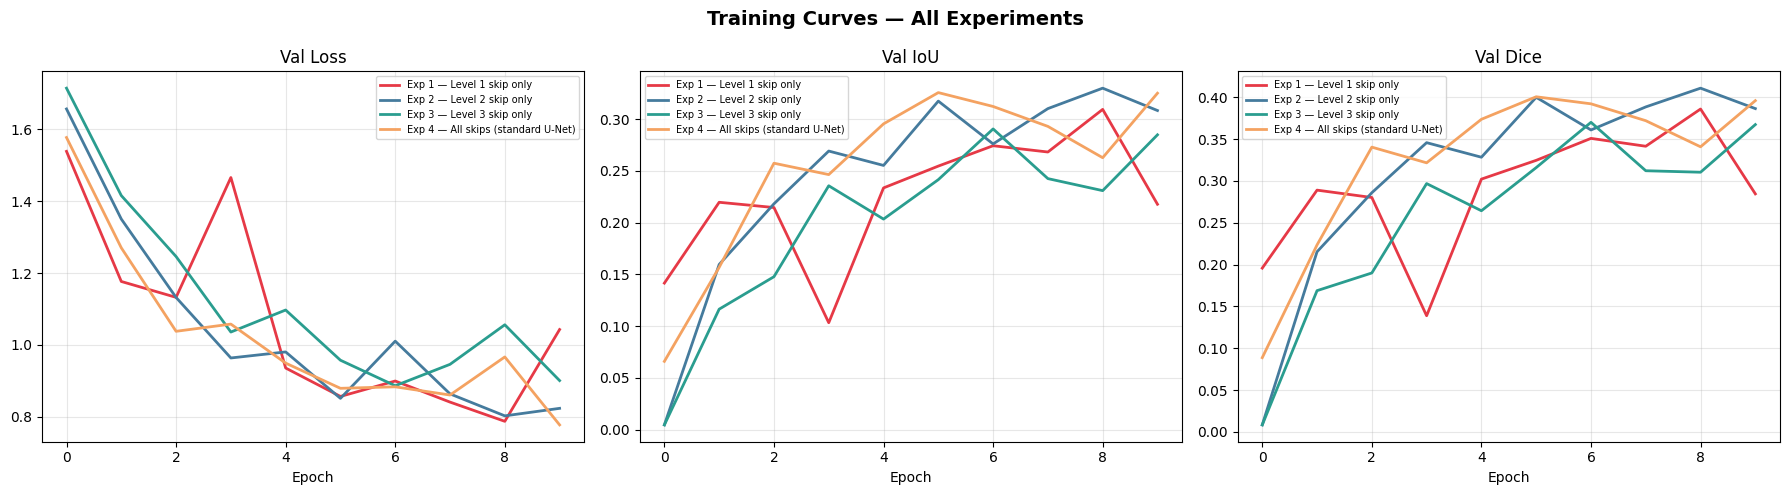

In [22]:
# ── Training curves ───────────────────────────────────────────────────────────
colors = ['#e63946','#457b9d','#2a9d8f','#f4a261']
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Training Curves — All Experiments', fontsize=14, fontweight='bold')
for ax, (key, title) in zip(axes, [('vl_loss','Val Loss'),('vl_iou','Val IoU'),('vl_dice','Val Dice')]):
    for (name,_), col in zip(EXPERIMENTS, colors):
        ax.plot(all_histories[name][key], label=LABELS[name], color=col, lw=2)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

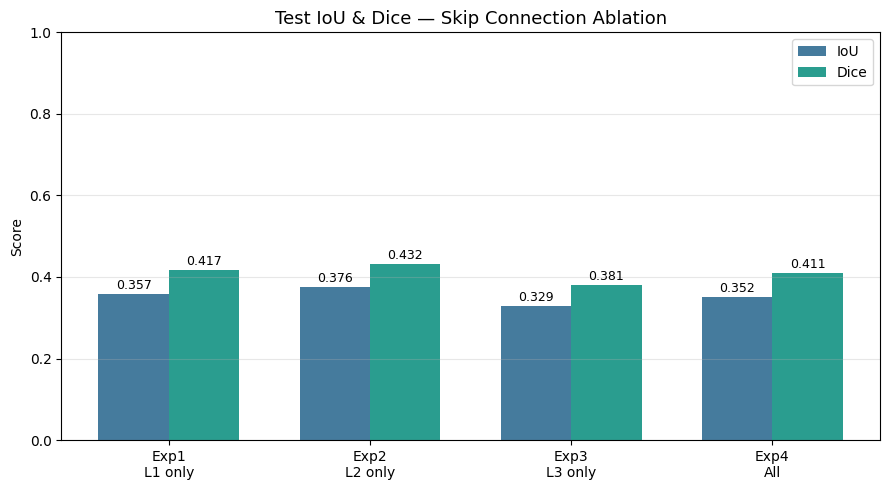

In [23]:
# ── Bar chart ─────────────────────────────────────────────────────────────────
iou_vals  = [all_metrics[n]['iou']  for n,_ in EXPERIMENTS]
dice_vals = [all_metrics[n]['dice'] for n,_ in EXPERIMENTS]
xlabels   = ['Exp1\nL1 only','Exp2\nL2 only','Exp3\nL3 only','Exp4\nAll']
x, w = np.arange(4), 0.35

fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x-w/2, iou_vals,  w, label='IoU',  color='#457b9d')
b2 = ax.bar(x+w/2, dice_vals, w, label='Dice', color='#2a9d8f')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylim(0,1); ax.set_ylabel('Score')
ax.set_title('Test IoU & Dice — Skip Connection Ablation', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/metrics_bar.png', dpi=130, bbox_inches='tight')
plt.show()

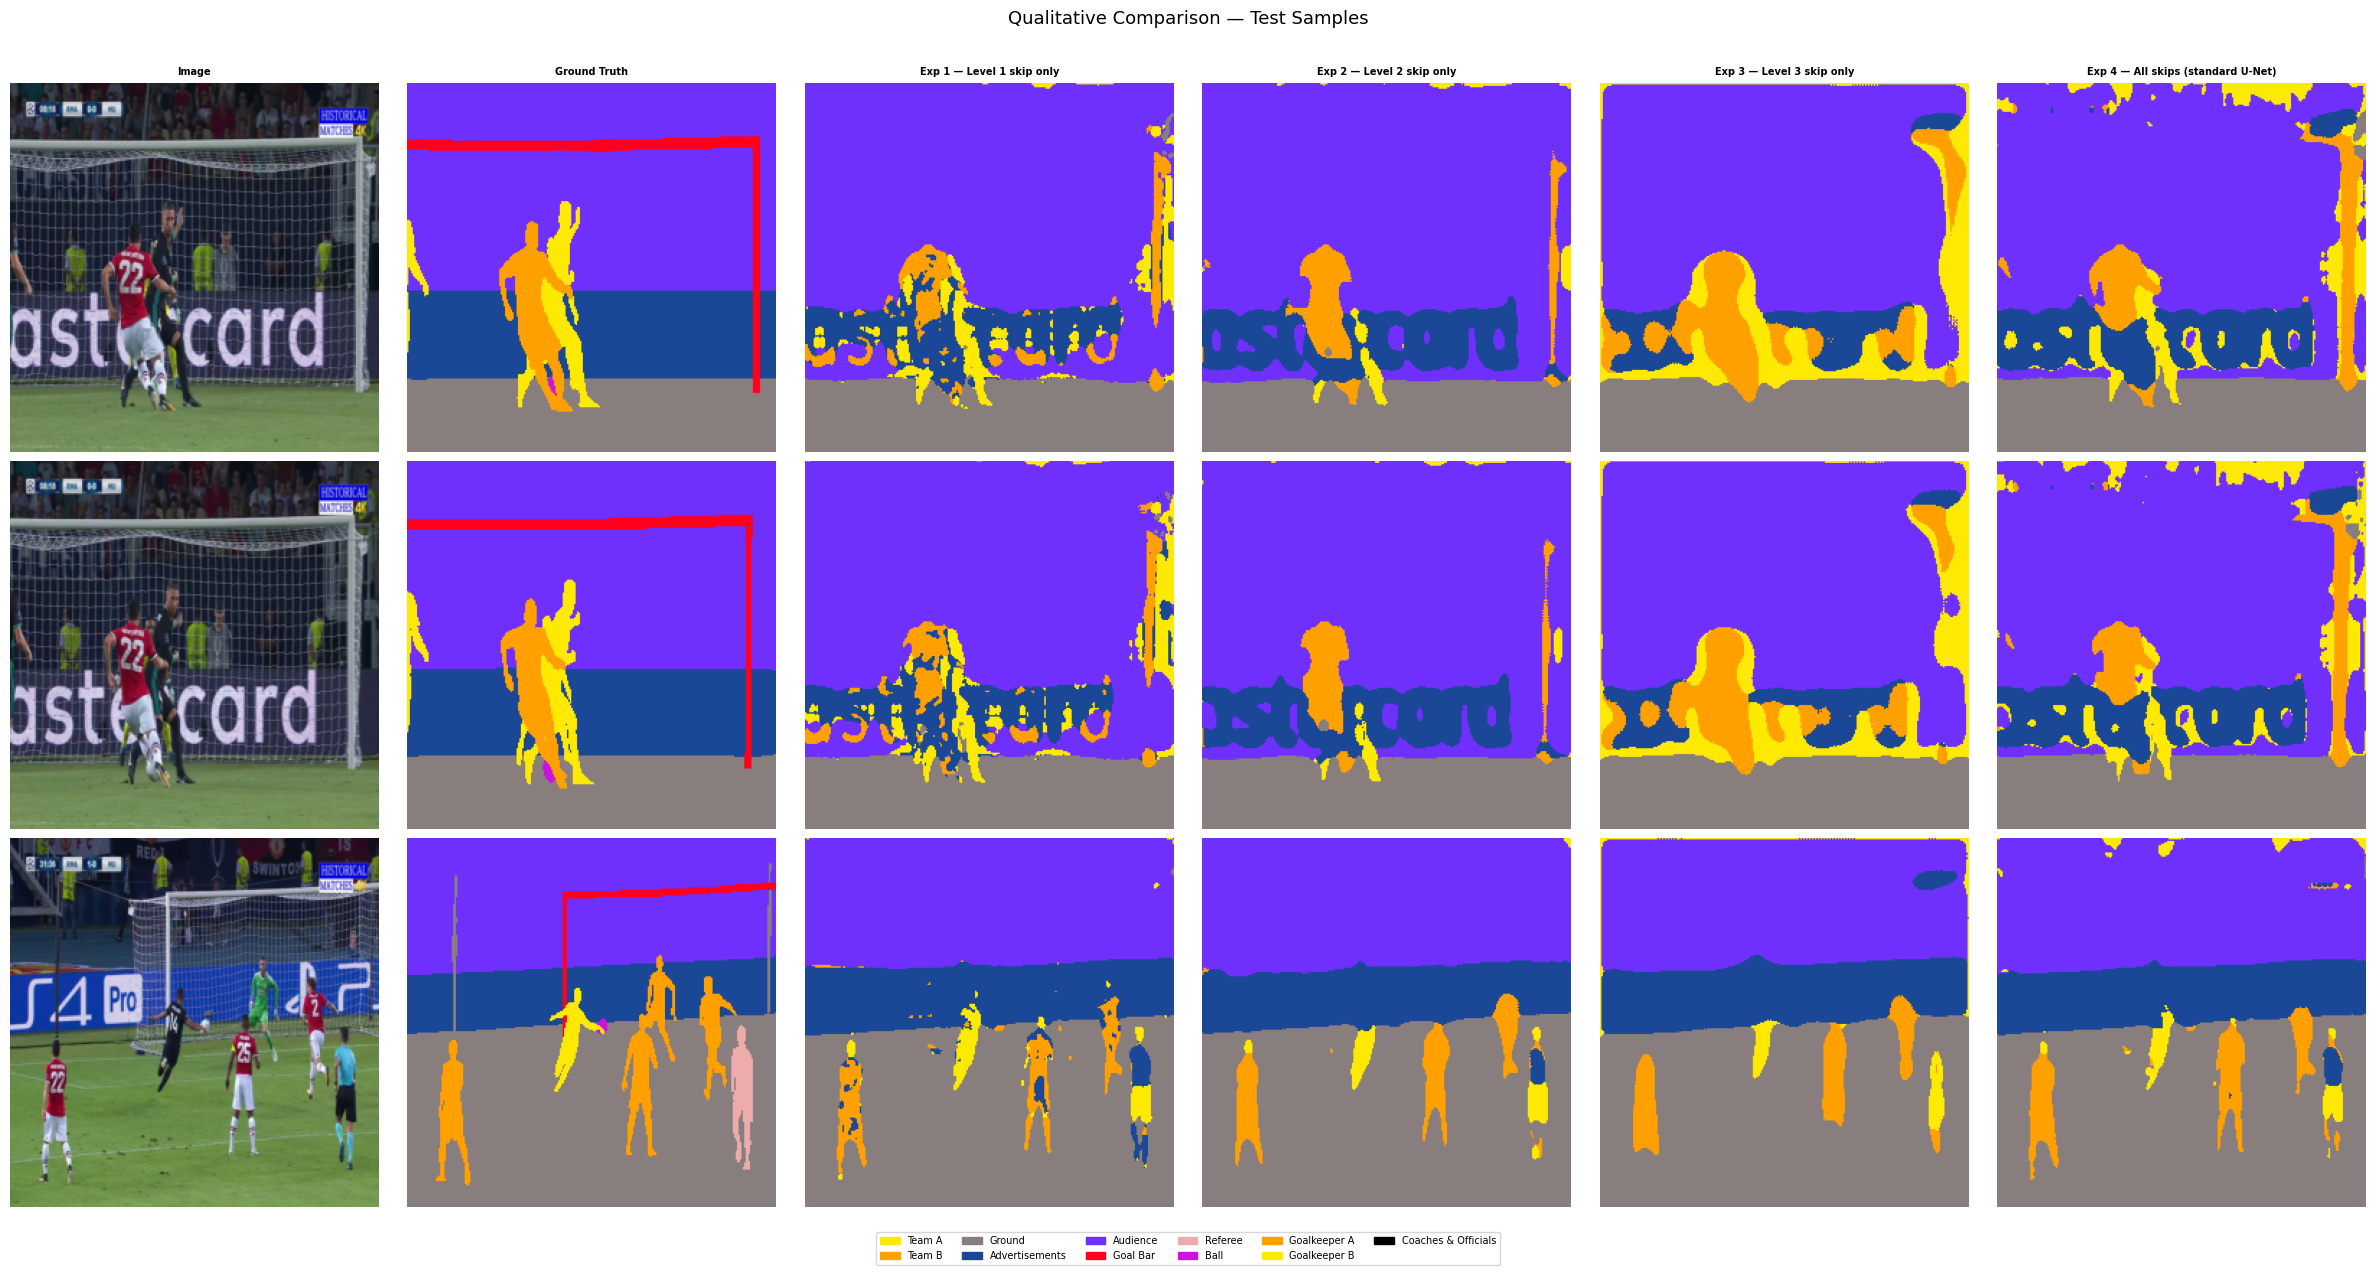

In [25]:
# ── Qualitative comparison ────────────────────────────────────────────────────
@torch.no_grad()
def predict(model, img_tensor):
    model.eval()
    return model(img_tensor.unsqueeze(0).to(DEVICE)).argmax(dim=1)[0].cpu().numpy()

test_imgs, test_masks = next(iter(test_loader))
n_show = min(3, test_imgs.size(0))
n_cols  = 2 + len(EXPERIMENTS)

fig, axes = plt.subplots(n_show, n_cols, figsize=(4*n_cols, 4*n_show))
col_titles = ['Image','Ground Truth'] + [LABELS[n] for n,_ in EXPERIMENTS]
for j,t in enumerate(col_titles): axes[0,j].set_title(t, fontsize=7, fontweight='bold')

for i in range(n_show):
    axes[i,0].imshow(denorm(test_imgs[i])); axes[i,0].axis('off')
    axes[i,1].imshow(colorise(test_masks[i].numpy())); axes[i,1].axis('off')
    for j,(name,_) in enumerate(EXPERIMENTS):
        pred = predict(all_models[name], test_imgs[i])
        axes[i,j+2].imshow(colorise(pred)); axes[i,j+2].axis('off')

patches = [mpatches.Patch(color=[c/255 for c in color], label=CLASS_NAMES[idx])
           for color, idx in COLOR_TO_CLASS.items()]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=7, bbox_to_anchor=(0.5,-0.04))
plt.suptitle('Qualitative Comparison — Test Samples', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/qualitative.png', dpi=130, bbox_inches='tight')
plt.show()

In [26]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '='*58)
print('  FINAL TEST RESULTS')
print('='*58)
print(f'{"Experiment":<38} {"IoU":>8} {"Dice":>8}')
print('-'*58)
for name,_ in EXPERIMENTS:
    te = all_metrics[name]
    print(f'{LABELS[name]:<38} {te["iou"]:>8.4f} {te["dice"]:>8.4f}')
print('='*58)


  FINAL TEST RESULTS
Experiment                                  IoU     Dice
----------------------------------------------------------
Exp 1 — Level 1 skip only                0.3573   0.4172
Exp 2 — Level 2 skip only                0.3763   0.4317
Exp 3 — Level 3 skip only                0.3290   0.3805
Exp 4 — All skips (standard U-Net)       0.3519   0.4107


## Conclusion

The results showed that **Exp 2**, which uses only the middle-level skip 
connection, achieved the best performance with **IoU=0.3763** and **Dice=0.4317**,
outperforming even the standard U-Net with all skip connections in **Exp 4**. 
This shows the fact that middle-level features achieving the optimal balance 
between semantic richness and spatial detail — they are abstract enough to distinguish 
classes like players, ground, and audience, in the other hand **Exp 3** with only the deepest skip performed worst **IoU=0.3290** because deeply downsampled features lack spatial precision, Overall, the experiments prove that a single well-placed skip connection can outperform a full U-Net on small datasets, as fewer active connections reduce model complexity and overfitting risk when training data is limited.

| Experiment | Active Skip Connection | Test IoU | Test Dice |
|------------|----------------------|----------|-----------|
| Exp 1 | Level 1 only (shallowest) | 0.3573 | 0.4172 |
| Exp 2 | Level 2 only (middle) | **0.3763** | **0.4317** |
| Exp 3 | Level 3 only (deepest) | 0.3290 | 0.3805 |
| Exp 4 | All skips (standard U-Net) | 0.3519 | 0.4107 |

# Thank You